### Load Dataset & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv('train.csv')

display(df.head())
display(df.info())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


None

## 1. Data Cleaning & Preparation

### Handle Missing Values

In [2]:
print("Missing values before cleaning:")
print(df.isnull().sum())

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(columns=['Cabin'])

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


### Feature Extraction: Passenger Title

In [3]:
df['Title'] = df['Name'].str.extract(r',\s*([^\.]*)\.')

title_counts = df['Title'].value_counts()
print(title_counts)

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


### Remove Duplicates

In [4]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

df = df.drop_duplicates()
print(f"Dataset shape after removing duplicates: {df.shape}")

Number of duplicate rows found: 0
Dataset shape after removing duplicates: (891, 12)


**Summary:** No duplicate rows were found in the dataset, so the full 891 passenger records were retained for analysis.

## 2. Summary Statistics & Correlation

### Summary Statistics for Numerical Columns

In [5]:
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']
display(df[numerical_cols].describe())

print("\nMode values:")
print(df[numerical_cols].mode().iloc[0])

,Age,Fare,SibSp,Parch
count,891.000000,891.000000,891.000000,891.000000
mean,29.361582,32.204208,0.523008,0.381594
std,13.019697,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,22.000000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,35.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000



Mode values:
Age      28.00
Fare      8.05
SibSp     0.00
Parch     0.00
Name: 0, dtype: float64


**Summary:** The average passenger age is around 29 years, with `Fare` showing a wide spread (up to £512) driven by a small number of high-paying first-class passengers. Most passengers traveled with 0 siblings/spouses (`SibSp`) and 0 parents/children (`Parch`), indicating a majority traveled alone or in small groups.

### Correlation Matrix

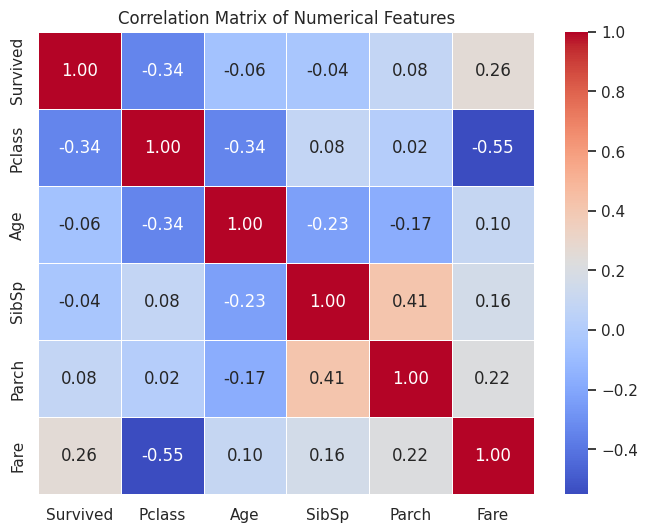

In [6]:
corr_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**Summary:** `Survived` has a moderate negative correlation with `Pclass` (-0.34), meaning passengers in lower (numerically higher) classes were less likely to survive. `Fare` correlates positively with survival (0.26), reinforcing that wealthier passengers had better survival odds. `Age` shows only a weak negative correlation with survival.

## 3. Demographic & Survival Insights

### Survival Rate by Gender

In [7]:
gender_survival = df.groupby(['Sex', 'Survived']).size().unstack()
gender_survival_rate = df.groupby('Sex')['Survived'].mean()

display(gender_survival)
print("\nSurvival rate by gender:")
print(gender_survival_rate)

Survived,0,1
Sex,,
female,81,233
male,468,109



Survival rate by gender:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


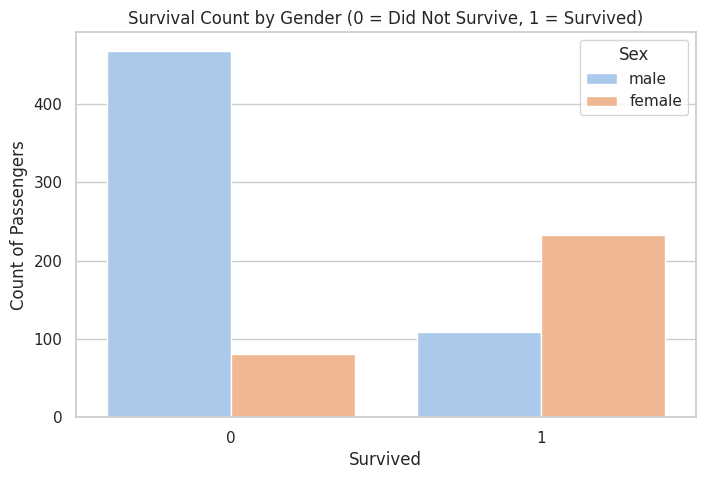

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Survived', hue='Sex', palette='pastel')
plt.title('Survival Count by Gender (0 = Did Not Survive, 1 = Survived)')
plt.xlabel('Survived')
plt.ylabel('Count of Passengers')
plt.legend(title='Sex')
plt.show()

## 4. Ticket Class & Economic Status Analysis

In [9]:
class_survival_rate = df.groupby('Pclass')['Survived'].mean()
class_avg_fare = df.groupby('Pclass')['Fare'].mean()

class_summary = pd.DataFrame({
    'Survival Rate': class_survival_rate,
    'Average Fare': class_avg_fare
})
display(class_summary)

,Survival Rate,Average Fare
Pclass,,
1,0.629630,84.154687
2,0.472826,20.662183
3,0.242363,13.675550


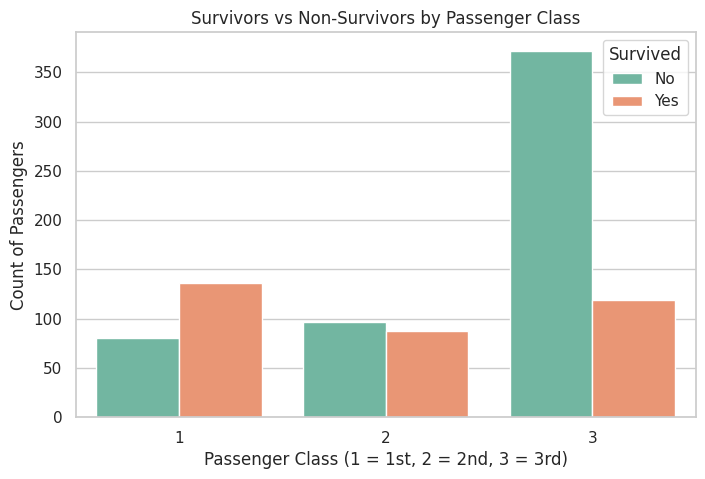

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Pclass', hue='Survived', palette='Set2')
plt.title('Survivors vs Non-Survivors by Passenger Class')
plt.xlabel('Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)')
plt.ylabel('Count of Passengers')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

## 5. Age Distribution & Outlier Analysis

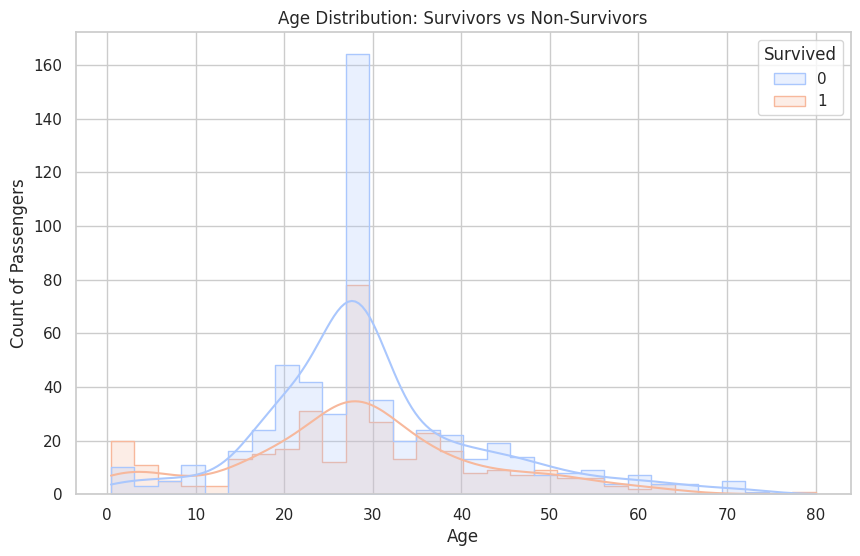

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Survived', kde=True, bins=30, palette='coolwarm', element='step')
plt.title('Age Distribution: Survivors vs Non-Survivors')
plt.xlabel('Age')
plt.ylabel('Count of Passengers')
plt.show()

/tmp/ipykernel_587/62596827.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pclass', y='Fare', palette='Set3')


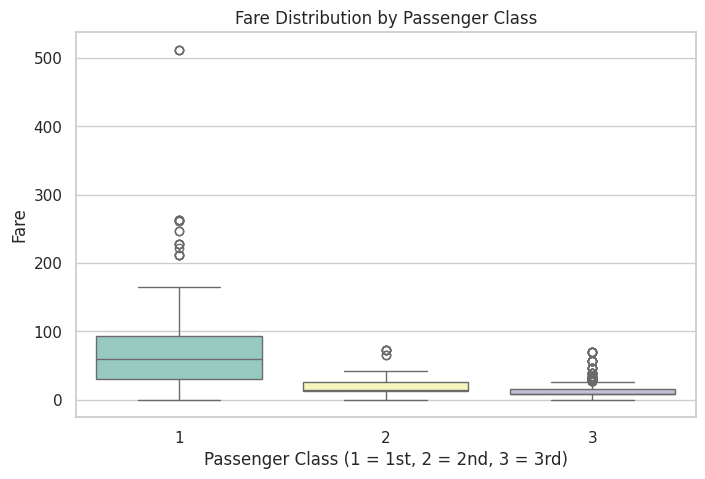

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Pclass', y='Fare', palette='Set3')
plt.title('Fare Distribution by Passenger Class')
plt.xlabel('Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)')
plt.ylabel('Fare')
plt.show()

## 6. Family Size & Behavioral Segmentation

In [13]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

def categorize_family(size):
    if size == 1:
        return 'Solo'
    elif 2 <= size <= 4:
        return 'Small Family'
    else:
        return 'Large Family'

df['FamilyType'] = df['FamilySize'].apply(categorize_family)

display(df[['FamilySize', 'FamilyType']].head())
print("\nPassenger count by family type:")
print(df['FamilyType'].value_counts())

,FamilySize,FamilyType
0,2,Small Family
1,2,Small Family
2,1,Solo
3,2,Small Family
4,1,Solo



Passenger count by family type:
FamilyType
Solo            537
Small Family    292
Large Family     62
Name: count, dtype: int64


/tmp/ipykernel_587/1210440760.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=family_survival.index, y=family_survival.values, palette='muted')


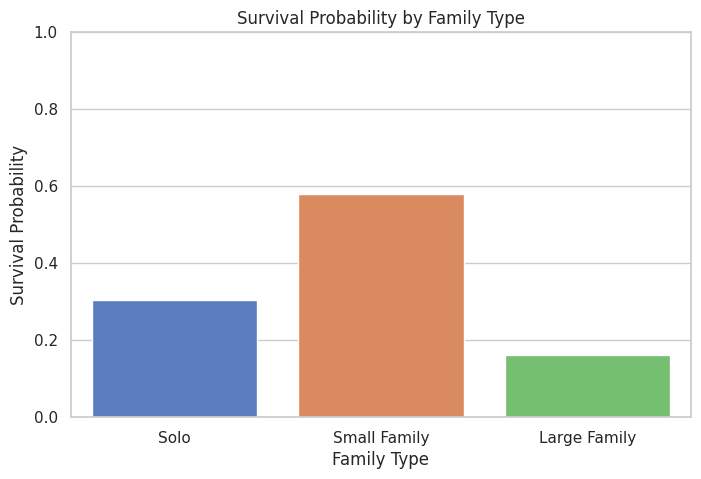

In [14]:
family_survival = df.groupby('FamilyType')['Survived'].mean().reindex(['Solo', 'Small Family', 'Large Family'])

plt.figure(figsize=(8, 5))
sns.barplot(x=family_survival.index, y=family_survival.values, palette='muted')
plt.title('Survival Probability by Family Type')
plt.xlabel('Family Type')
plt.ylabel('Survival Probability')
plt.ylim(0, 1)
plt.show()